In [21]:
import pandas as pd
music_df = pd.read_csv('music.csv')
music_dummies = pd.get_dummies(music_df["genre"], drop_first=True)
print(music_dummies.head())

   Anime  Blues  Classical  Country  Electronic  Hip-Hop   Jazz    Rap   Rock
0  False  False      False    False       False    False   True  False  False
1  False  False      False    False       False    False  False   True  False
2  False  False      False    False        True    False  False  False  False
3  False  False      False    False       False    False  False  False   True
4  False  False      False    False       False    False  False   True  False


In [22]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score, train_test_split


music_dummies = pd.concat([music_df, music_dummies], axis = 1)
music_dummies = music_dummies.drop('genre', axis=1)
X = music_dummies.drop('popularity', axis=1).values
y = music_dummies['popularity'].values
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,
random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
linreg = LinearRegression()
linreg_cv = cross_val_score(linreg, X_train, y_train, cv=kf,
scoring='neg_mean_squared_error')
print(np.sqrt(-linreg_cv))

[8.14828914 8.63267535 7.56370022 8.61139914 7.91041513]


In [23]:
# Load the music_unclean dataset
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix

# Load music_df from music_unclean.csv
music_df = pd.read_csv('music_unclean.csv')

# Print number of missing values for each column, sorted in ascending order
print("Missing values per column (sorted ascending):")
print(music_df.isnull().sum().sort_values())

Missing values per column (sorted ascending):
Unnamed: 0            0
genre                 8
popularity           31
loudness             44
liveness             46
tempo                46
speechiness          59
duration_ms          91
instrumentalness     91
valence             143
danceability        143
acousticness        200
energy              200
dtype: int64


In [24]:
# Remove values for columns with 50 or fewer missing values
# Get columns with 50 or fewer missing values
cols_to_clean = music_df.columns[music_df.isnull().sum() <= 50]
print(f"Columns with <= 50 missing values: {list(cols_to_clean)}")

# Drop rows with missing values in those columns
music_df = music_df.dropna(subset=cols_to_clean)
print(f"Dataset shape after dropping: {music_df.shape}")

Columns with <= 50 missing values: ['Unnamed: 0', 'popularity', 'liveness', 'loudness', 'tempo', 'genre']
Dataset shape after dropping: (892, 13)


In [25]:
# Convert genre to binary: 1 if "Rock", else 0
music_df["genre"] = music_df["genre"].apply(lambda x: 1 if x == "Rock" else 0)

# Check the conversion
print("Genre distribution after conversion:")
print(music_df["genre"].value_counts())

Genre distribution after conversion:
genre
0    446
1    446
Name: count, dtype: int64


In [26]:
# Define X and y
X = music_df.drop("genre", axis=1)
y = music_df["genre"]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (892, 12)
y shape: (892,)


In [27]:
# Split data with test_size=30 and random_state=42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=30, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (862, 12)
X_test shape: (30, 12)


In [28]:
# Instantiate an imputer
imputer = SimpleImputer()

# Instantiate a KNN classifier with 3 neighbors
knn = KNeighborsClassifier(n_neighbors=3)

In [29]:
# Create steps: a list of tuples
steps = [("imputer", imputer), ("knn", knn)]

# Create pipeline using the steps
pipeline = Pipeline(steps)

In [30]:
# Fit the pipeline to the training data
pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred = pipeline.predict(X_test)

print("Predictions on test set:")
print(y_pred)

Predictions on test set:
[1 1 0 0 1 1 0 1 0 1 0 1 1 1 1 1 0 1 1 0 1 1 0 0 0 0 1 0 0 0]


In [31]:
# Calculate and print the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# Optional: Print accuracy and more details
from sklearn.metrics import accuracy_score, classification_report
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[6 7]
 [8 9]]

Accuracy: 0.5000

Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.46      0.44        13
           1       0.56      0.53      0.55        17

    accuracy                           0.50        30
   macro avg       0.50      0.50      0.49        30
weighted avg       0.50      0.50      0.50        30

              precision    recall  f1-score   support

           0       0.43      0.46      0.44        13
           1       0.56      0.53      0.55        17

    accuracy                           0.50        30
   macro avg       0.50      0.50      0.49        30
weighted avg       0.50      0.50      0.50        30



In [32]:
# ============================
# SAME TASK WITHOUT PIPELINE
# ============================

# Load the music_unclean dataset
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Load music_df from music_unclean.csv
music_df = pd.read_csv('music_unclean.csv')

# Print number of missing values for each column, sorted in ascending order
print("Missing values per column (sorted ascending):")
print(music_df.isnull().sum().sort_values())

Missing values per column (sorted ascending):
Unnamed: 0            0
genre                 8
popularity           31
loudness             44
liveness             46
tempo                46
speechiness          59
duration_ms          91
instrumentalness     91
valence             143
danceability        143
acousticness        200
energy              200
dtype: int64


In [33]:
# Remove values for columns with 50 or fewer missing values
cols_to_clean = music_df.columns[music_df.isnull().sum() <= 50]
print(f"Columns with <= 50 missing values: {list(cols_to_clean)}")

# Drop rows with missing values in those columns
music_df = music_df.dropna(subset=cols_to_clean)
print(f"Dataset shape after dropping: {music_df.shape}")

Columns with <= 50 missing values: ['Unnamed: 0', 'popularity', 'liveness', 'loudness', 'tempo', 'genre']
Dataset shape after dropping: (892, 13)


In [34]:
# Convert genre to binary: 1 if "Rock", else 0
music_df["genre"] = music_df["genre"].apply(lambda x: 1 if x == "Rock" else 0)

# Check the conversion
print("Genre distribution after conversion:")
print(music_df["genre"].value_counts())

Genre distribution after conversion:
genre
0    446
1    446
Name: count, dtype: int64


In [35]:
# Define X and y
X = music_df.drop("genre", axis=1)
y = music_df["genre"]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (892, 12)
y shape: (892,)


In [36]:
# Split data with test_size=30 and random_state=42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=30, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (862, 12)
X_test shape: (30, 12)


In [37]:
# Instantiate imputer
imputer = SimpleImputer()

# Fit imputer on training data only, then transform both train and test
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

print("Imputation complete!")
print(f"X_train_imputed shape: {X_train_imputed.shape}")
print(f"X_test_imputed shape: {X_test_imputed.shape}")

Imputation complete!
X_train_imputed shape: (862, 12)
X_test_imputed shape: (30, 12)


In [38]:
# Instantiate a KNN classifier with 3 neighbors
knn = KNeighborsClassifier(n_neighbors=3)

# Fit KNN on the imputed training data
knn.fit(X_train_imputed, y_train)

print("KNN model trained on imputed data!")

KNN model trained on imputed data!


In [39]:
# Make predictions on the imputed test set
y_pred = knn.predict(X_test_imputed)

print("Predictions on test set:")
print(y_pred)

Predictions on test set:
[1 1 0 0 1 1 0 1 0 1 0 1 1 1 1 1 0 1 1 0 1 1 0 0 0 0 1 0 0 0]


In [40]:
# Calculate and print the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[6 7]
 [8 9]]

Accuracy: 0.5000

Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.46      0.44        13
           1       0.56      0.53      0.55        17

    accuracy                           0.50        30
   macro avg       0.50      0.50      0.49        30
weighted avg       0.50      0.50      0.50        30



In [41]:
# ============================
# FIND THE BEST K VALUE
# ============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load and prepare data (same preprocessing as before)
music_df = pd.read_csv('music_unclean.csv')

# Drop rows with missing values for columns with <= 50 missing values
cols_to_clean = music_df.columns[music_df.isnull().sum() <= 50]
music_df = music_df.dropna(subset=cols_to_clean)

# Convert genre to binary
music_df["genre"] = music_df["genre"].apply(lambda x: 1 if x == "Rock" else 0)

# Define X and y
X = music_df.drop("genre", axis=1)
y = music_df["genre"]

In [42]:
# Test K values from 1 to 20 for both test_size values
k_values = range(1, 21)
test_sizes = [0.2, 0.3]

# Store results
results = {0.2: [], 0.3: []}

# Create imputer (fit once on full X to get consistent imputation)
imputer = SimpleImputer()
X_imputed = imputer.fit_transform(X)

print("Testing K values from 1 to 20...\n")

for test_size in test_sizes:
    print(f"--- test_size = {test_size} ---")
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X_imputed, y, test_size=test_size, random_state=42
    )
    
    accuracies = []
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train, y_train)
        y_pred = knn.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        accuracies.append(acc)
        if k <= 5 or k % 5 == 0:
            print(f"K={k}: Accuracy = {acc:.4f}")
    
    results[test_size] = accuracies
    best_k = k_values[np.argmax(accuracies)]
    best_acc = max(accuracies)
    print(f"Best K for test_size={test_size}: K={best_k} with accuracy={best_acc:.4f}\n")

Testing K values from 1 to 20...

--- test_size = 0.2 ---
K=1: Accuracy = 0.4749
K=2: Accuracy = 0.5419
K=3: Accuracy = 0.4972
K=4: Accuracy = 0.5140
K=5: Accuracy = 0.5028
K=10: Accuracy = 0.5642
K=15: Accuracy = 0.5642
K=20: Accuracy = 0.5363
Best K for test_size=0.2: K=11 with accuracy=0.5810

--- test_size = 0.3 ---
K=1: Accuracy = 0.5037
K=2: Accuracy = 0.5299
K=3: Accuracy = 0.5112
K=4: Accuracy = 0.5075
K=5: Accuracy = 0.5299
K=10: Accuracy = 0.4963
K=15: Accuracy = 0.5112
K=20: Accuracy = 0.5672
Best K for test_size=0.3: K=20 with accuracy=0.5672



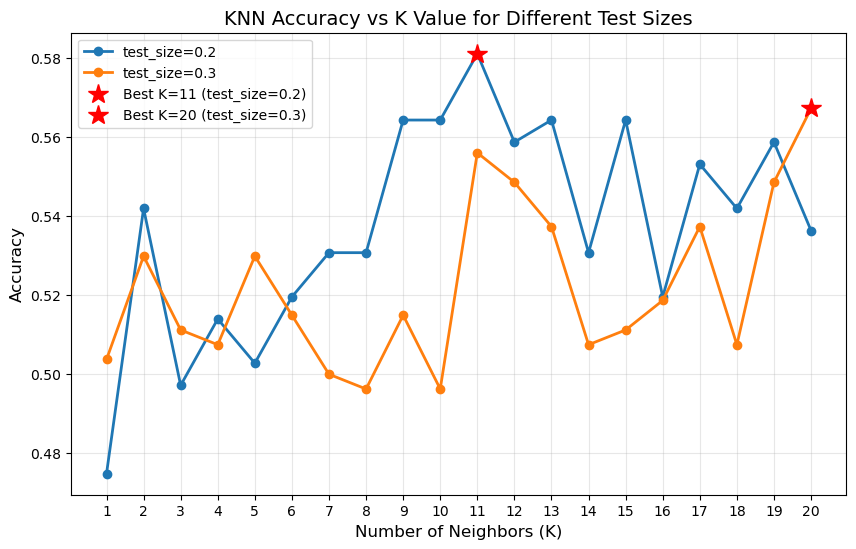


SUMMARY: Best K Values
Test Size    Best K   Accuracy  
--------------------------------------------------
0.2          11       0.5810
0.3          20       0.5672


In [43]:
# Plot accuracy vs K for both test sizes
plt.figure(figsize=(10, 6))

for test_size in test_sizes:
    plt.plot(k_values, results[test_size], marker='o', 
             label=f'test_size={test_size}', linewidth=2)

# Mark best K for each test size
for test_size in test_sizes:
    best_idx = np.argmax(results[test_size])
    best_k = k_values[best_idx]
    best_acc = results[test_size][best_idx]
    plt.plot(best_k, best_acc, 'r*', markersize=15, 
             label=f'Best K={best_k} (test_size={test_size})')

plt.xlabel('Number of Neighbors (K)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('KNN Accuracy vs K Value for Different Test Sizes', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
plt.show()

# Summary table
print("\n" + "="*50)
print("SUMMARY: Best K Values")
print("="*50)
print(f"{'Test Size':<12} {'Best K':<8} {'Accuracy':<10}")
print("-" * 50)
for test_size in test_sizes:
    best_idx = np.argmax(results[test_size])
    best_k = k_values[best_idx]
    best_acc = results[test_size][best_idx]
    print(f"{test_size:<12} {best_k:<8} {best_acc:.4f}")